<a href="https://colab.research.google.com/github/RosarioH10062002/geetha-2026-pd-connectivity_analysis/blob/main/GLM_Functional_Connectivity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRARIES**

In [143]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from pathlib import Path
import re
import inspect
import math
from collections import Counter
from scipy.io import loadmat,savemat
import scipy.io as sio
try:
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure

except ImportError:
    !pip install nilearn
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure
    from nilearn.plotting import plot_glass_brain, show

try:
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat
except:
  !pip install neuroHarmonize
  !pip install neuroCombat
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat

try:
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.analysis import GrangerAnalyzer
  from nitime.timeseries import TimeSeries
  from nitime.viz import drawmatrix_channels

except ImportError:
  !pip install nitime
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.viz import drawmatrix_channels
# GLM
import statsmodels.api as sm
# STATISTICAL TESTS
from statsmodels.stats.multitest import multipletests, fdrcorrection
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOAD DATA**

In [144]:
ROOT_PATH = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/python_to_matlab")

In [145]:
root_path_pd = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD")
root_path_pd_dep = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD_DEP")
root_path_ctrl = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_CTRL")
all_participants_path = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/all_part.csv")
all_participants = pd.read_csv(all_participants_path, sep = ",")

In [146]:
def get_dataframe(status):
  if status == "PARTICIPANTS":
    df = pd.read_csv(all_participants_path, sep = ",")
  return df
def clean_df(all_participants):
  all_participants = all_participants[all_participants["Description"].str.startswith("rsfMRI_RL")]
  filtered_df = all_participants.drop_duplicates(subset = "Subject ID")
  return filtered_df

def get_manufacturer(list_participants, status):
  raw_participants = pd.read_csv(all_participants_path)
  all_participants = clean_df(raw_participants)
  list_d = [int(x) for x in list_participants if x.isdigit()]
  mask = all_participants["Subject ID"].isin(list_d)
  filtered_df = all_participants[mask]
  df_siemens = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
  df_philips = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
  df_ge = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
  print(f"{status}  = Siemens: {df_siemens.shape[0]}, Philips: {df_philips.shape[0]}, GE:{df_ge.shape[0]}")
  return df_siemens, df_philips, df_ge

In [147]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_participants[all_participants["Description"] == "rsfMRI_RL_split_2"]

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol


In [148]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_siemens = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
print(f"Siemens: {all_siemens.shape}")
all_philips = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
print(f"Philips: {all_philips.shape}")
all_ge = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
print(f"GE Medical Systems: {all_ge.shape}")

def segment_groups(df,name):
  df_pd = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] < 5)]
  df_pd_dep = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] >= 5)]
  #df_pd_dep = df[df["Research Group"] == "PD"]
  df_ctrl = df[df["Research Group"] == "Control"]
  print(f"Name: {name}")
  print(f"PD: {df_pd.shape[0]}, PD_DEP: {df_pd_dep.shape[0]}, CTRL: {df_ctrl.shape[0]}")
  return df_pd, df_ctrl, df_pd_dep

df_pd_siemens, df_ctrl_siemens, df_pdd_siemens = segment_groups(df = all_siemens, name = "Siemens")
df_pd_philips, df_ctrl_philips, df_pdd_philips = segment_groups(df = all_philips, name = "Philips")
df_pd_ge, df_ctrl_ge, df_pdd_ge = segment_groups(df = all_ge, name = "GE")

# Total 176, 31, 40

Siemens: (179, 8)
Philips: (57, 8)
GE Medical Systems: (48, 8)
Name: Siemens
PD: 129, PD_DEP: 21, CTRL: 25
Name: Philips
PD: 28, PD_DEP: 6, CTRL: 5
Name: GE
PD: 19, PD_DEP: 4, CTRL: 10


In [149]:
list_participants_pd = os.listdir(root_path_pd)
df_siemens_pd, df_philips_pd, df_ge_pd = get_manufacturer(list_participants_pd, status = "PD")

list_participants_pdd = os.listdir(root_path_pd_dep)
df_siemens_pdd, df_philips_pdd, df_ge_pdd = get_manufacturer(list_participants_pdd, status = "PDD")

list_participants_ctrl = os.listdir(root_path_ctrl)
df_siemens_ctrl, df_philips_ctrl, df_ge_ctrl = get_manufacturer(list_participants_ctrl, status = "CTRL")

PD  = Siemens: 24, Philips: 4, GE:4
PDD  = Siemens: 18, Philips: 4, GE:4
CTRL  = Siemens: 24, Philips: 4, GE:4


In [150]:
def get_new_participants(total_list, actual_list):
  mask_new_participants = ~total_list["Subject ID"].isin(actual_list["Subject ID"])
  return total_list[mask_new_participants]

In [151]:
get_new_participants(total_list = df_pdd_siemens, actual_list = df_siemens_pdd).sort_values(by = "GDSCALE Total Score", ascending = True) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
15,100012,F,PD,67.0,5.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
545,141135,M,PD,53.2,5.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
328,110219,M,PD,73.2,7.0,fMRI,"rsfMRI_RL (no music, awake, eyes open)",Manufacturer=SIEMENS;TR=2500.0


In [152]:
get_new_participants(total_list = df_pd_siemens, actual_list = df_siemens_pd).sort_values(by = "GDSCALE Total Score", ascending = True).head(10) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
301,107099,M,PD,63.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
169,101482,M,PD,59.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
486,136681,M,PD,54.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
473,133486,M,PD,61.0,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
455,130013,M,PD,64.4,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
445,127741,M,PD,70.1,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
407,116870,M,PD,51.0,0.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
429,121626,M,PD,76.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
461,130156,M,PD,61.7,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
681,152031,M,PD,77.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0


In [153]:
def get_description_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Description"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [154]:
description_pd = get_description_list(list_participants = list_participants_pd)
print(description_pd)
print(len(description_pd))
print(np.sum(description_pd == "rsfMRI_RL_split_1"))
description_pdd = get_description_list(list_participants = list_participants_pdd)
print(len(description_pdd))
print(np.sum(description_pdd == "rsfMRI_RL_split_1"))

['rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL_split_1'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL']
32
1
26
5


In [155]:
def get_manufacturers_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Imaging Protocol"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [156]:
def get_sex_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_sex = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                sex = all_participants.loc[subj, "Sex"]
                list_sex.append(sex)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_sex)

In [157]:
def get_age_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_age = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                age = all_participants.loc[subj, "Age"]
                list_age.append(age)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_age)

In [158]:
def get_gdsc_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_gdsc = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                gdsc = all_participants.loc[subj, "GDSCALE Total Score"]
                list_gdsc.append(gdsc)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_gdsc)

In [159]:
def get_missing_participants(raw_participants, status,  manufacturer, depressed):
  all_participants = clean_df(raw_participants)
  if depressed == True:
    all_participants = all_participants[all_participants["GDSCALE Total Score"] >= 5.0] #depressed status

  mask_status = all_participants["Research Group"] == status
  mask_manufacturer = all_participants["Imaging Protocol"] == f"Manufacturer={manufacturer};TR=2500.0"

  filtered_df = all_participants[
      mask_status & mask_manufacturer
  ]
  filtered_df = filtered_df.sort_values(
      by="GDSCALE Total Score", ascending=False
  )
  #print(filtered_df.shape)
  df_siemens, df_philips, df_ge = get_manufacturer(list_participants_pdd, status = "PDD")
  diff_df = filtered_df[~filtered_df["Subject ID"].isin(df_siemens["Subject ID"])]
  return diff_df
#raw_participants = pd.read_csv(all_participants_path)
#get_missing_participants(raw_participants, status = "PD",  manufacturer = "SIEMENS", depressed = True)

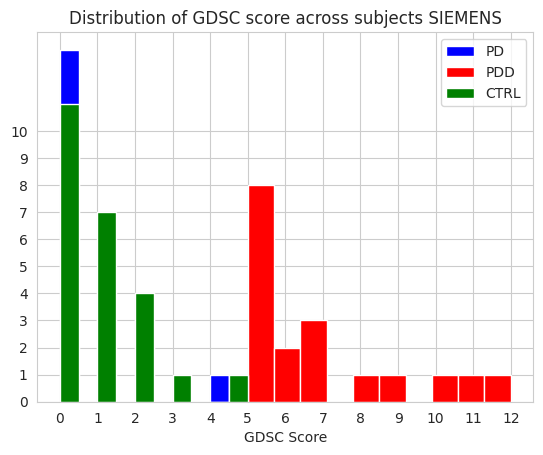

In [160]:
plt.hist(df_siemens_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_siemens_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_siemens_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects SIEMENS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

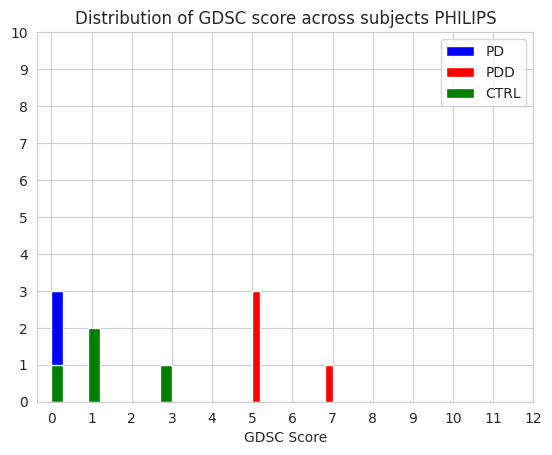

In [161]:
plt.hist(df_philips_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_philips_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_philips_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects PHILIPS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

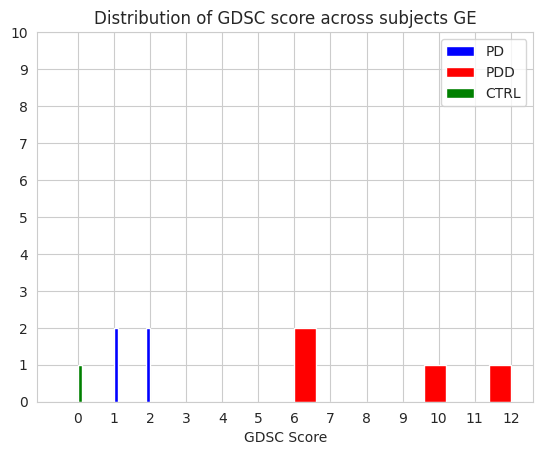

In [162]:
plt.hist(df_ge_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_ge_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_ge_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects GE")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

In [163]:
def get_list_paths(list_participants, root_dir):
  paths = {}
  gdsc_list= []
  for subject in list_participants:
      mat_path = (
          root_dir
          / str(subject)
          / str(subject)
          / "data"
          / "ROI_Subject001_Session001.mat"
      )
      paths[subject] = mat_path
      gdsc = all_participants[all_participants["Subject ID"]==int(subject)]["GDSCALE Total Score"].iloc[0]
      if math.isnan(gdsc):
        gdsc = 0
      gdsc_list.append(int(gdsc))
      #print(gdsc)
      #print(subject, "->", mat_path.exists())
  return paths, gdsc_list

In [164]:
paths, gdsc_ctrl = get_list_paths(list_participants_ctrl, root_path_ctrl)
paths, gdsc_pd = get_list_paths(list_participants_pd, root_path_pd)
paths, gdsc_pdd = get_list_paths(list_participants_pdd, root_path_pd_dep)

In [165]:
def get_roi_names():
  X_list, roi_interest_names = get_list_roi_matrix(status = "PD")
  return roi_interest_names

In [166]:
#@title EXTRACT THE REGIONS OF INTEREST
def get_individual_roi_matrix(path_name):
  path_try = loadmat(path_name)
  names = path_try["names"]
  data = path_try["data"]
  roi_names = [n[0] if isinstance(n, np.ndarray) else n for n in names[0]]
  #roi_names
  roi_idx = [
      i for i, name in enumerate(roi_names)
      if name.startswith(("networks.DefaultMode.",
                          "networks.Salience.",
                          "networks.FrontoParietal."))
  ]
  roi_interest_names = [roi_names[i] for i in roi_idx]
  roi_interest_data = [data[0, i] for i in roi_idx]
  X_interest = np.column_stack([np.asarray(arr).squeeze() for arr in roi_interest_data])
  #print("X_interest shape:", X_interest.shape)
  return X_interest, roi_interest_names

In [167]:
def get_list_roi_matrix(status):
  X_list = []
  if status ==  "PD":
    path_names, gdsc = get_list_paths(list_participants_pd, root_path_pd)
  if status ==  "PDD":
    path_names, gdsc = get_list_paths(list_participants_pdd, root_path_pd_dep)
  if status ==  "CTRL":
    path_names, gdsc = get_list_paths(list_participants_ctrl, root_path_ctrl)

  for path in path_names.values():
    X_interest, roi_interest_names = get_individual_roi_matrix(path)
    X_list.append(X_interest)
  return X_list, roi_interest_names

#**Harmonization Technique**

In [168]:
#@title Combat Harmonization Variables

def get_harmonization (matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl):
  X = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl])
  group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

  batch_pd = get_manufacturers_list(list_participants_pd)
  batch_pdd = get_manufacturers_list(list_participants_pdd)
  batch_ctrl = get_manufacturers_list(list_participants_ctrl)
  batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])

  age_pd = get_age_list(list_participants_pd)
  age_pdd = get_age_list(list_participants_pdd)
  age_ctrl = get_age_list(list_participants_ctrl)
  age = np.concatenate([age_pd, age_pdd, age_ctrl])

  sex_pd = get_sex_list(list_participants_pd)
  sex_pdd = get_sex_list(list_participants_pdd)
  sex_ctrl = get_sex_list(list_participants_ctrl)
  sex = np.concatenate([sex_pd, sex_pdd, sex_ctrl])
  sex_encoded = (np.array(sex) == "F").astype(int)

  gdsc_pd = get_gdsc_list(list_participants_pd)
  gdsc_pdd = get_gdsc_list(list_participants_pdd)
  gdsc_ctrl = get_gdsc_list(list_participants_ctrl)
  gdsc = np.concatenate([gdsc_pd, gdsc_pdd, gdsc_ctrl])


  #batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
  #batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

  print(X.shape)
  print(len(group))
  print(len(batch))

  group_dummies = pd.get_dummies(group, prefix="GROUP", drop_first=True)

  covars = pd.DataFrame({
        "SITE": batch,
        "AGE": age,
        "SEX": sex_encoded
    })

  covars = pd.concat([covars, group_dummies], axis=1)

  #print(covars.head())
  model, X_harmonized = harmonizationLearn(
      data = X,
      covars = covars
  )
  print(model.keys())
  print(X.shape, X_harmonized.shape)
  print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())
  return model, X_harmonized, group, batch, age, sex_encoded, gdsc
#model, X_harmonized = get_harmonization (matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl)

In [169]:
def plot_combat_distributions(X_before, X_after, group, site, age=None, sex=None):

    def to_dataframe(X, label):
        data = []
        for i in range(X.shape[0]):
            for val in X[i]:
                data.append({
                    "value": val,
                    "group": group[i],
                    "site": site[i],
                    "age": age[i] if age is not None else None,
                    "sex": sex[i] if sex is not None else None,
                    "stage": label
                })
        return pd.DataFrame(data)

    df_before = to_dataframe(X_before, "Before ComBat")
    df_after  = to_dataframe(X_after, "After ComBat")
    df = pd.concat([df_before, df_after]).reset_index(drop=True)

    if age is not None:
        df["age"] = df["age"].astype(float)
        df["age_bin"] = pd.qcut(df["age"], q=3, labels=["Young", "Middle", "Old"])

    HEIGHT = 4
    ASPECT = 1.2
    TITLE_Y = 1.05

    sns.set_style("whitegrid")

    g1 = sns.FacetGrid(df, col="stage", hue="site",
                       sharex=True, sharey=True,
                       height=HEIGHT, aspect=ASPECT)

    g1.map(sns.kdeplot, "value", fill=True, alpha=0.4)
    g1.add_legend(title="Site")
    g1._legend.set_bbox_to_anchor((1.05, 0.5))

    g1.fig.suptitle("Distributions by SITE", y=TITLE_Y)
    g1.fig.tight_layout()
    plt.show()

    g2 = sns.FacetGrid(df, col="stage", hue="group",
                       sharex=True, sharey=True,
                       height=HEIGHT, aspect=ASPECT)

    g2.map(sns.kdeplot, "value", fill=True, alpha=0.4)
    g2.add_legend(title="Group")
    g2._legend.set_bbox_to_anchor((1.05, 0.5))

    g2.fig.suptitle("Distributions by GROUP", y=TITLE_Y)
    g2.fig.tight_layout()
    plt.show()

    if age is not None:
        g3 = sns.FacetGrid(df, col="stage", hue="age_bin",
                           sharex=True, sharey=True,
                           height=HEIGHT, aspect=ASPECT)

        g3.map(sns.kdeplot, "value", fill=True, alpha=0.4)
        g3.add_legend(title="Age group")
        g3._legend.set_bbox_to_anchor((1.05, 0.5))

        g3.fig.suptitle("Distributions by AGE", y=TITLE_Y)
        g3.fig.tight_layout()
        plt.show()

    if sex is not None:
        # optional: map 0/1 → labels
        df["sex_label"] = np.where(df["sex"] == 1, "F", "M")

        g4 = sns.FacetGrid(df, col="stage", hue="sex_label",
                           sharex=True, sharey=True,
                           height=HEIGHT, aspect=ASPECT)

        g4.map(sns.kdeplot, "value", fill=True, alpha=0.4)
        g4.add_legend(title="Sex")
        g4._legend.set_bbox_to_anchor((1.05, 0.5))

        g4.fig.suptitle("Distributions by SEX", y=TITLE_Y)
        g4.fig.tight_layout()
        plt.show()

#**Functional Connectivity**

In [170]:
#@title STATIC FUNCTIONAL CONNECTIVITY
def compute_fc_matrix(status):
  fc_matrix_list = []
  X_list,roi_interest_names = get_list_roi_matrix(status)
  for x in X_list:
    fc_matrix = np.corrcoef(x.T)
    fc_matrix = np.clip(fc_matrix, -0.999999, 0.999999)
    fc_matrix = np.arctanh(fc_matrix)
    np.fill_diagonal(fc_matrix, 0)
    fc_matrix_list.append(fc_matrix)
  return np.array(fc_matrix_list)

def flatten_fc(matrix):
  return matrix[np.triu_indices_from(matrix, k = 1)]

def get_all_flatten(matrix_list):
  matrix_flatten = []
  for matrix in matrix_list:
    temp_matrix = flatten_fc(matrix)
    matrix_flatten.append(temp_matrix)
  return np.array(matrix_flatten)

In [171]:
fc_matrix_list_pd = compute_fc_matrix(status = "PD")
matrix_flatten_pd = get_all_flatten(fc_matrix_list_pd)

print(fc_matrix_list_pd.shape)
print(matrix_flatten_pd.shape)
fc_matrix_list_pdd = compute_fc_matrix(status = "PDD")
matrix_flatten_pdd = get_all_flatten(fc_matrix_list_pdd)
print(fc_matrix_list_pdd.shape)
print(matrix_flatten_pdd.shape)
fc_matrix_list_ctrl = compute_fc_matrix(status = "CTRL")
matrix_flatten_ctrl = get_all_flatten(fc_matrix_list_ctrl)
print(fc_matrix_list_ctrl.shape)
print(matrix_flatten_ctrl.shape)

(32, 15, 15)
(32, 105)
(26, 15, 15)
(26, 105)
(32, 15, 15)
(32, 105)


(90, 105)
90
90
dict_keys(['design', 'SITE_labels', 'var_pooled', 'B_hat', 'stand_mean', 'mod_mean', 'gamma_star', 'delta_star', 'info_dict', 'gamma_hat', 'delta_hat', 'gamma_bar', 't2', 'a_prior', 'b_prior', 'smooth_model', 'eb', 'SITE_labels_train', 'Covariates', 'ref_batch'])
(90, 105) (90, 105)
0 0


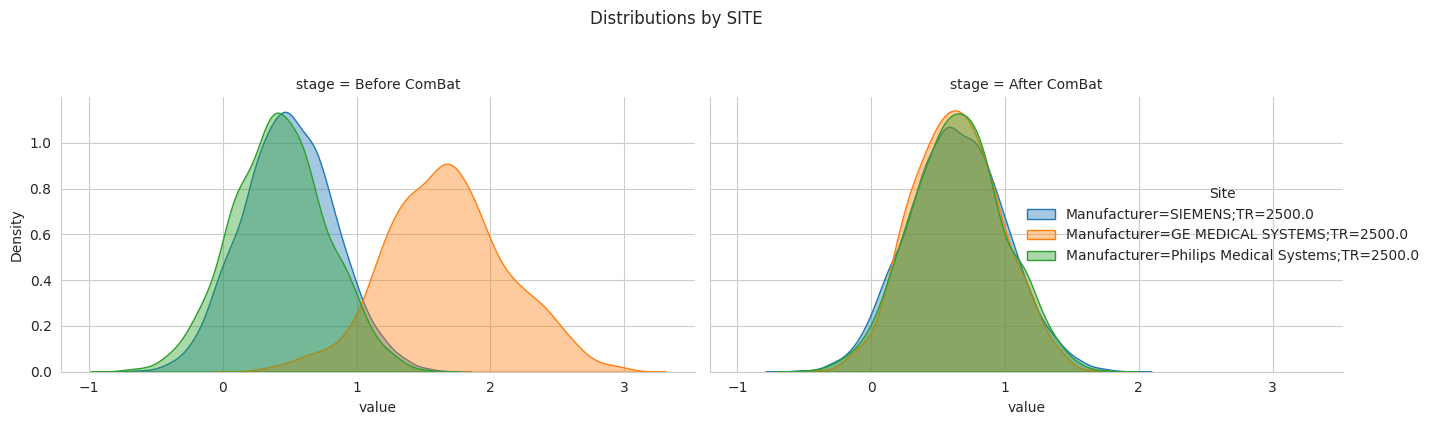

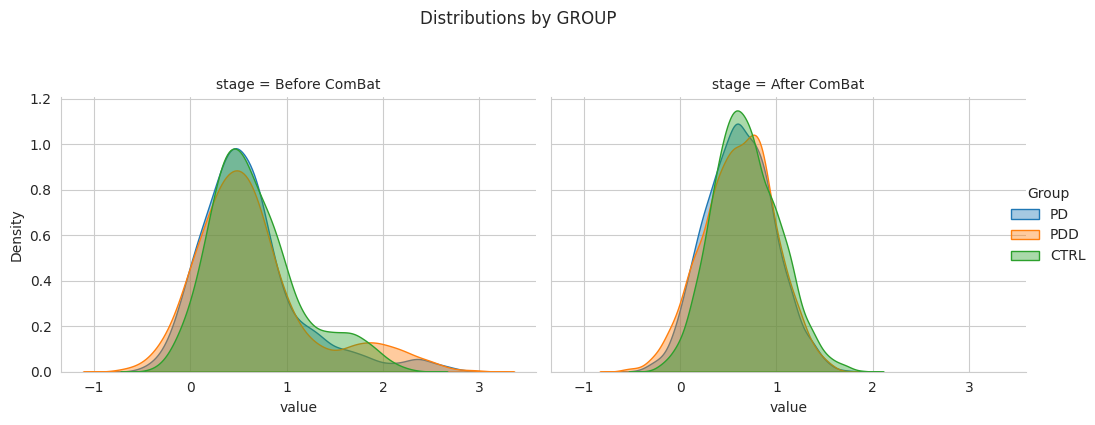

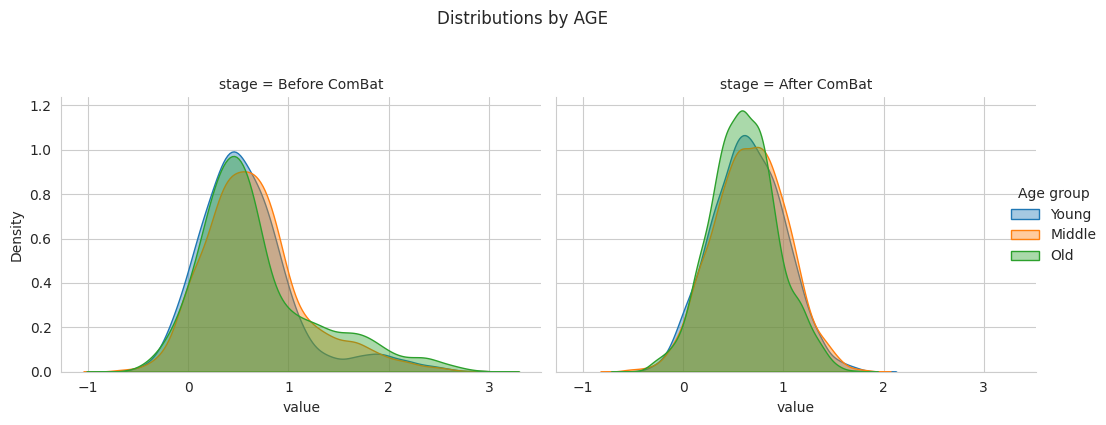

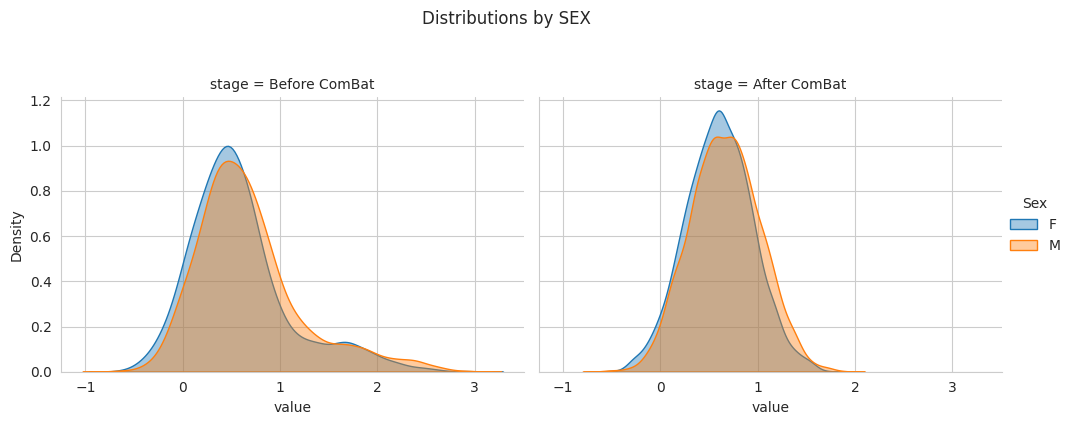

In [172]:
#@title Harmonization
model, X_harmonized, group, batch, age, sex, gdsc = get_harmonization(
    matrix_flatten_pd,
    matrix_flatten_pdd,
    matrix_flatten_ctrl
)

plot_combat_distributions(
    X_before = np.vstack([matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl]),
    X_after  = X_harmonized,
    group    = group,
    site     = batch,
    age      = age,
    sex      = sex
)

In [173]:
print(X_harmonized.shape)
print(len(group))
print(age.shape)
print(sex.shape)
print(batch.shape)

(90, 105)
90
(90,)
(90,)
(90,)


In [174]:
#@title GLM MODEL
meta = pd.DataFrame({
    "Group": group,
    "Age": age,
    "Sex": sex
})

print(meta.head())

  Group   Age  Sex
0    PD  72.5    1
1    PD  55.7    1
2    PD  52.8    0
3    PD  67.2    0
4    PD  69.7    1


In [175]:
#@title CTRL vs PD, PDD
group_dummies = pd.get_dummies(
    meta["Group"],
    drop_first=True #CTRL is my reference
)

group_dummies = group_dummies.astype(int)
print(group_dummies.head())


   PD  PDD
0   1    0
1   1    0
2   1    0
3   1    0
4   1    0


In [176]:
X_design = pd.concat([
    group_dummies,
    meta[["Age","Sex"]]
],axis=1)

X_design = sm.add_constant(X_design)

print(X_design.head())

   const  PD  PDD   Age  Sex
0    1.0   1    0  72.5    1
1    1.0   1    0  55.7    1
2    1.0   1    0  52.8    0
3    1.0   1    0  67.2    0
4    1.0   1    0  69.7    1


In [177]:
beta_PD = []
beta_PDD = []

p_PD = []
p_PDD = []

for edge in range(X_harmonized.shape[1]):

    y = X_harmonized[:,edge]

    fit = sm.OLS(
        y,
        X_design
    ).fit()

    beta_PD.append(
        fit.params["PD"]
    )

    beta_PDD.append(
        fit.params["PDD"]
    )

    p_PD.append(
        fit.pvalues["PD"]
    )

    p_PDD.append(
        fit.pvalues["PDD"]
    )

beta_PD = np.array(beta_PD)
beta_PDD = np.array(beta_PDD)

p_PD = np.array(p_PD)
p_PDD = np.array(p_PDD)

In [178]:
reject_PD, p_fdr_PD = fdrcorrection(
    p_PD,
    alpha=0.05
)

reject_PDD, p_fdr_PDD = fdrcorrection(
    p_PDD,
    alpha=0.05
)

In [179]:
results = pd.DataFrame({
    "edge": np.arange(105),

    "beta_PD": beta_PD,
    "p_PD": p_PD,
    "p_fdr_PD": p_fdr_PD,

    "beta_PDD": beta_PDD,
    "p_PDD": p_PDD,
    "p_fdr_PDD": p_fdr_PDD
})

results.sort_values(
    "p_PDD"
).head(20)

,edge,beta_PD,p_PD,p_fdr_PD,beta_PDD,p_PDD,p_fdr_PDD
37,37,-0.105295,0.107577,0.470648,-0.220528,0.001924,0.202018
32,32,-0.100125,0.164633,0.500822,-0.208590,0.007388,0.292863
33,33,-0.180980,0.012213,0.463469,-0.200021,0.009339,0.292863
31,31,-0.164598,0.028759,0.463469,-0.189069,0.018498,0.292863
22,22,-0.066377,0.417749,0.674826,-0.200684,0.023084,0.292863
28,28,-0.153852,0.073077,0.463469,-0.204727,0.025751,0.292863
17,17,-0.106497,0.125215,0.489472,-0.163905,0.027702,0.292863
50,50,-0.141656,0.074663,0.463469,-0.186779,0.027935,0.292863
43,43,-0.134067,0.051159,0.463469,-0.159648,0.029512,0.292863
8,8,-0.146827,0.077344,0.463469,-0.192685,0.030128,0.292863


In [180]:
mask = meta["Group"].isin([
    "PD",
    "PDD"
])

X_sub = X_harmonized[mask]

meta_sub = meta[
    mask
].copy()

In [181]:
meta_sub["PDD"] = (
    meta_sub["Group"]=="PDD"
).astype(int)

print(
    meta_sub[
        ["Group","PDD"]
    ].head()
)

  Group  PDD
0    PD    0
1    PD    0
2    PD    0
3    PD    0
4    PD    0


In [182]:
X_design_sub = meta_sub[
    [
        "PDD",
        "Age",
        "Sex"
    ]
]

X_design_sub = sm.add_constant(
    X_design_sub
)

print(
    X_design_sub.head()
)

   const  PDD   Age  Sex
0    1.0    0  72.5    1
1    1.0    0  55.7    1
2    1.0    0  52.8    0
3    1.0    0  67.2    0
4    1.0    0  69.7    1


In [183]:
beta = []
pvals = []

for edge in range(
    X_sub.shape[1]
):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    beta.append(
        fit.params["PDD"]
    )

    pvals.append(
        fit.pvalues["PDD"]
    )

beta = np.array(beta)
pvals = np.array(pvals)

In [184]:
reject,p_fdr = fdrcorrection(
    pvals,
    alpha=0.05
)

In [185]:
results_pd_pdd = pd.DataFrame({
    "edge":np.arange(105),
    "beta":beta,
    "p":pvals,
    "p_fdr":p_fdr,
    "sig":reject
})

results_pd_pdd.sort_values(
    "p"
).head(20)

,edge,beta,p,p_fdr,sig
80,80,0.141877,0.055489,0.96217,False
81,81,0.120352,0.071056,0.96217,False
78,78,0.112512,0.086622,0.96217,False
37,37,-0.108544,0.089723,0.96217,False
92,92,0.113387,0.111781,0.96217,False
0,0,-0.112877,0.130534,0.96217,False
91,91,0.120719,0.133843,0.96217,False
22,22,-0.126236,0.139179,0.96217,False
62,62,-0.093460,0.149641,0.96217,False
32,32,-0.104500,0.154792,0.96217,False


In [186]:
def run_glm_fc(
    X_fc,
    meta,
    predictors,
    target="PDD",
    fdr=True
):

    X_design = meta[predictors].copy()

    X_design = sm.add_constant(
        X_design
    )

    betas = []
    pvals = []

    for edge in range(
        X_fc.shape[1]
    ):

        y = X_fc[:,edge]

        fit = sm.OLS(
            y,
            X_design
        ).fit()

        betas.append(
            fit.params[target]
        )

        pvals.append(
            fit.pvalues[target]
        )

    betas = np.array(betas)
    pvals = np.array(pvals)

    if fdr:

        reject,p_fdr = fdrcorrection(
            pvals,
            alpha=0.05
        )

    else:

        reject = np.zeros(
            len(pvals)
        )

        p_fdr = pvals

    results = pd.DataFrame({

        "edge":
        np.arange(
            len(betas)
        ),

        "beta":
        betas,

        "p":
        pvals,

        "p_fdr":
        p_fdr,

        "sig":
        reject
    })

    return results.sort_values(
        "p"
    )

In [187]:
meta.groupby(
    "Group"
)["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
CTRL,32.0,65.668750,12.572254,32.2,58.600,67.30,76.075,85.3
PD,32.0,64.056250,10.685563,39.4,58.475,65.55,71.450,82.4
PDD,26.0,62.907692,9.925036,41.9,55.925,63.70,69.075,80.5


In [188]:
pd.crosstab(
    meta["Group"],
    meta["Sex"]
)

Sex,0,1
Group,,
CTRL,18,14
PD,19,13
PDD,18,8


In [189]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

pvals = []
effect = []

for edge in range(X_sub.shape[1]):

    pd_values = X_sub[
        meta_sub["PDD"]==0,
        edge
    ]

    pdd_values = X_sub[
        meta_sub["PDD"]==1,
        edge
    ]

    stat,p = mannwhitneyu(
        pd_values,
        pdd_values,
        alternative="two-sided"
    )

    pvals.append(p)

    effect.append(
        np.mean(pdd_values)
        -
        np.mean(pd_values)
    )

pvals = np.array(pvals)

reject,p_fdr = fdrcorrection(
    pvals
)

results_mw = pd.DataFrame({
    "edge":np.arange(105),
    "effect":effect,
    "p":pvals,
    "p_fdr":p_fdr,
    "sig":reject
})

results_mw.sort_values(
    "p"
).head(20)

,edge,effect,p,p_fdr,sig
78,78,0.113215,0.031568,0.990725,False
0,0,-0.125905,0.032826,0.990725,False
81,81,0.117893,0.055453,0.990725,False
80,80,0.141630,0.061706,0.990725,False
15,15,-0.097061,0.092805,0.990725,False
37,37,-0.117402,0.123544,0.990725,False
36,36,-0.066543,0.131351,0.990725,False
1,1,-0.123440,0.131351,0.990725,False
92,92,0.113014,0.157073,0.990725,False
22,22,-0.124174,0.157073,0.990725,False


In [190]:
from scipy.stats import shapiro

normal_edges = []
non_normal_edges = []

for edge in range(X_sub.shape[1]):

    stat,p = shapiro(
        X_sub[:,edge]
    )

    if p > 0.05:
        normal_edges.append(edge)

    else:
        non_normal_edges.append(edge)

print(
    "Normal:",
    len(normal_edges)
)

print(
    "Non normal:",
    len(non_normal_edges)
)

Normal: 94
Non normal: 11


In [191]:
fit = sm.OLS(
    X_sub[:,0],
    X_design_sub
).fit()

shapiro(
    fit.resid
)

ShapiroResult(statistic=np.float64(0.9776963020015758), pvalue=np.float64(0.360937001739125))

In [192]:
normal_resid = []
non_normal_resid = []

for edge in range(X_sub.shape[1]):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    stat,p = shapiro(
        fit.resid
    )

    if p > 0.05:
        normal_resid.append(edge)

    else:
        non_normal_resid.append(edge)

print(
    "Normal residuals:",
    len(normal_resid)
)

print(
    "Non normal residuals:",
    len(non_normal_resid)
)

Normal residuals: 95
Non normal residuals: 10


In [193]:
from statsmodels.stats.diagnostic import het_breuschpagan

homogeneous = []
heterogeneous = []

for edge in range(X_sub.shape[1]):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    bp = het_breuschpagan(
        fit.resid,
        fit.model.exog
    )

    p = bp[1]

    if p > 0.05:

        homogeneous.append(edge)

    else:

        heterogeneous.append(edge)

print(
    "Homogeneous:",
    len(homogeneous)
)

print(
    "Heterogeneous:",
    len(heterogeneous)
)

Homogeneous: 98
Heterogeneous: 7


In [194]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X_design_sub.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_design_sub.values,
        i
    )

    for i in range(
        X_design_sub.shape[1]
    )
]

print(vif)

  Variable        VIF
0    const  41.484972
1      PDD   1.012141
2      Age   1.029118
3      Sex   1.036666


In [195]:
mask_valid = ~np.isnan(gdsc)

meta_gds = meta[
    mask_valid
].copy()

X_gds = X_harmonized[
    mask_valid
]

print(X_gds.shape)
print(meta_gds.shape)

(87, 105)
(87, 3)


In [196]:
meta_gds["GDS"] = gdsc[mask_valid]
results_gds = run_glm_fc(
    X_fc = X_gds,

    meta = meta_gds,

    predictors = [
        "GDS",
        "Age",
        "Sex"
    ],

    target = "GDS"
)

display(
    results_gds.head(20)
)

,edge,beta,p,p_fdr,sig
37,37,-0.023332,0.011707,0.892914,False
32,32,-0.021428,0.033765,0.892914,False
22,22,-0.023941,0.036295,0.892914,False
8,8,-0.021936,0.056253,0.892914,False
16,16,-0.017981,0.078201,0.892914,False
0,0,-0.015307,0.105528,0.892914,False
43,43,-0.015201,0.112752,0.892914,False
81,81,0.013864,0.117700,0.892914,False
53,53,-0.017451,0.124013,0.892914,False
45,45,-0.015665,0.129998,0.892914,False


In [197]:
roi_interest_names = get_roi_names()

print(len(roi_interest_names))
print(roi_interest_names)

n_roi = len(roi_interest_names)

iu = np.triu_indices(
    n_roi,
    k=1
)

edge_names = []

for i,j in zip(
    iu[0],
    iu[1]
):

    edge_names.append(
        f"{roi_interest_names[i]} -> {roi_interest_names[j]}"
    )

print(len(edge_names))

15
[np.str_('networks.DefaultMode.MPFC (1,55,-3)'), np.str_('networks.DefaultMode.LP (L) (-39,-77,33)'), np.str_('networks.DefaultMode.LP (R) (47,-67,29)'), np.str_('networks.DefaultMode.PCC (1,-61,38)'), np.str_('networks.Salience.ACC (0,22,35)'), np.str_('networks.Salience.AInsula (L) (-44,13,1)'), np.str_('networks.Salience.AInsula (R) (47,14,0)'), np.str_('networks.Salience.RPFC (L) (-32,45,27)'), np.str_('networks.Salience.RPFC (R) (32,46,27)'), np.str_('networks.Salience.SMG (L) (-60,-39,31)'), np.str_('networks.Salience.SMG (R) (62,-35,32)'), np.str_('networks.FrontoParietal.LPFC (L)  (-43,33,28)'), np.str_('networks.FrontoParietal.PPC (L)  (-46,-58,49)'), np.str_('networks.FrontoParietal.LPFC (R)  (41,38,30)'), np.str_('networks.FrontoParietal.PPC (R)  (52,-52,45)')]
105


In [198]:
pd.set_option(
    "display.max_colwidth",
    None
)

results_gds["edge_name"] = edge_names

display(
    results_gds[
        results_gds["p"] < 0.05
    ][[
        "edge_name",
        "beta",
        "p",
        "p_fdr"
    ]]
)

,edge_name,beta,p,p_fdr
37,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (L) (-39,-77,33)",-0.023332,0.011707,0.892914
32,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (R) (47,-67,29)",-0.021428,0.033765,0.892914
22,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.PCC (1,-61,38)",-0.023941,0.036295,0.892914


In [199]:
significant_results = results_gds[results_gds["p"] < 0.05]
n_roi = len(roi_interest_names)
adj_significant = np.zeros((n_roi, n_roi))

In [200]:
coords = [
    (1, 55, -3),   # mPFC
    (-39, -77, 33), # LP L
    (47, -67, 29),  # LP R
    (1,-61,38) # PCC
]

In [201]:
import re

adj_significant = np.zeros(
    (len(coords),len(coords))
)

for _,row in significant_results.iterrows():

    edge = row["edge_name"]

    src = edge.split("->")[0]
    tgt = edge.split("->")[1]

    src_idx = next(
        i for i,r in enumerate(
            roi_interest_names
        )
        if src.strip() == r.strip()
    )

    tgt_idx = next(
        i for i,r in enumerate(
            roi_interest_names
        )
        if tgt.strip() == r.strip()
    )

    adj_significant[
        src_idx,
        tgt_idx
    ] = row["beta"]

    adj_significant[
        tgt_idx,
        src_idx
    ] = row["beta"]

In [202]:
for i,j in zip(
    *np.where(adj_significant != 0)
):

    if i < j:

        print(
            roi_interest_names[i],
            "->",
            roi_interest_names[j]
        )

networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (L) (-39,-77,33)
networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.PCC (1,-61,38)


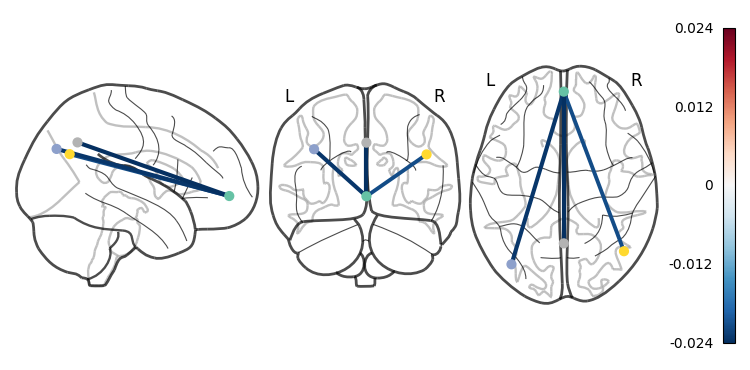

In [203]:
plotting.plot_connectome(
    adj_significant,
    coords,
    edge_threshold=0,
    display_mode="ortho",
    node_size=40
)

In [204]:
save_to_plot(
    adj_significant,
    coords,
    get_list_names(),
    name="GDS_DMN"
)

In [205]:
#Selecction of the mpfc nodes
edge_mpfc_lpl = 37
edge_mpfc_lpr = 32
edge_mpfc_pcc = 22

In [206]:
dmn_score = (
    X_gds[:, edge_mpfc_lpl] +
    X_gds[:, edge_mpfc_lpr] +
    X_gds[:, edge_mpfc_pcc]
) / 3

In [207]:
meta_gds["DMN_score"] = dmn_score

In [208]:
display(
    meta_gds[
        [
            "Group",
            "GDS",
            "DMN_score"
        ]
    ].head()
)

,Group,GDS,DMN_score
0,PD,0.0,0.463047
1,PD,2.0,0.629909
2,PD,0.0,0.546407
3,PD,0.0,0.927836
4,PD,5.0,0.596370


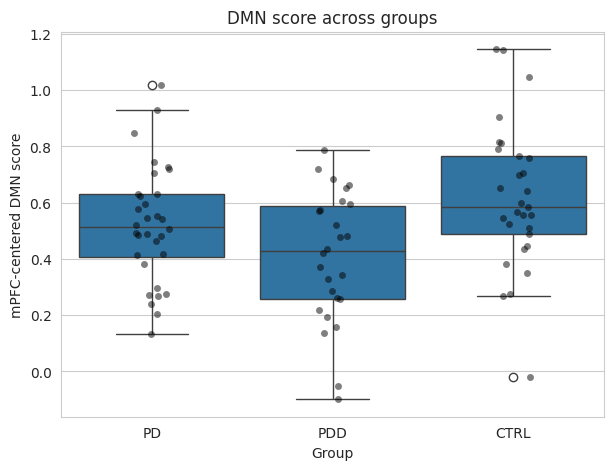

In [209]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=meta_gds,
    x="Group",
    y="DMN_score"
)

sns.stripplot(
    data=meta_gds,
    x="Group",
    y="DMN_score",

    color="black",
    alpha=0.5
)

plt.ylabel(
    "mPFC-centered DMN score"
)

plt.title(
    "DMN score across groups"
)

plt.show()

In [210]:
from scipy.stats import kruskal

ctrl = meta_gds.loc[
    meta_gds["Group"]=="CTRL",
    "DMN_score"
]

pd_ = meta_gds.loc[
    meta_gds["Group"]=="PD",
    "DMN_score"
]

pdd = meta_gds.loc[
    meta_gds["Group"]=="PDD",
    "DMN_score"
]

print(
    kruskal(
        ctrl,
        pd_,
        pdd
    )
)

KruskalResult(statistic=np.float64(9.050271202489569), pvalue=np.float64(0.010833245335279918))


In [211]:
from scipy.stats import mannwhitneyu

pairs = [
    ("CTRL","PD"),
    ("CTRL","PDD"),
    ("PD","PDD")
]

for g1,g2 in pairs:

    x = meta_gds.loc[
        meta_gds["Group"]==g1,
        "DMN_score"
    ]

    y = meta_gds.loc[
        meta_gds["Group"]==g2,
        "DMN_score"
    ]

    stat,p = mannwhitneyu(
        x,y,
        alternative="two-sided"
    )

    print(
        g1,
        g2,
        p
    )

CTRL PD 0.08971378961463826
CTRL PDD 0.004270422102966041
PD PDD 0.10228477073348033


In [212]:
meta_gds.groupby(
    "Group"
)["DMN_score"].agg(
    ["mean","std"]
)

,mean,std
Group,,
CTRL,0.618964,0.258711
PD,0.523090,0.208407
PDD,0.407198,0.232814


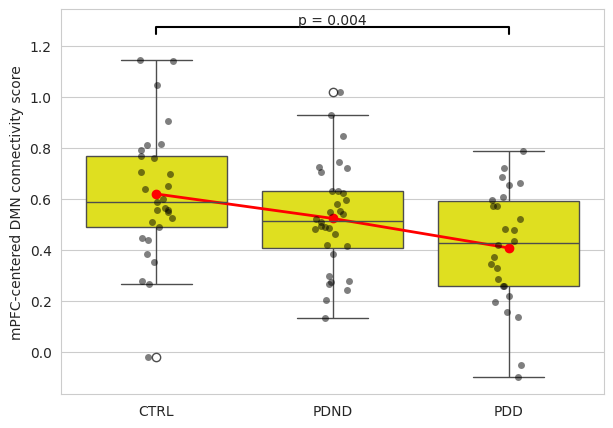

In [213]:
plt.figure(
    figsize=(7,5)
)

sns.boxplot(
    data=meta_gds,

    x="Group",

    y="DMN_score",

    order=[
        "CTRL",
        "PD",
        "PDD"
    ],
    color="yellow"
)

sns.stripplot(
    data=meta_gds,

    x="Group",

    y="DMN_score",

    order=[
        "CTRL",
        "PD",
        "PDD"
    ],

    color="black",

    alpha=0.5
)

means = (
    meta_gds
    .groupby(
        "Group"
    )["DMN_score"]
    .mean()
)

means = means.loc[
    [
        "CTRL",
        "PD",
        "PDD"
    ]
]

plt.plot(
    range(3),

    means,

    marker="o",

    linewidth=2,
    color = "red"
)

plt.ylabel(
    "mPFC-centered DMN connectivity score"
)

plt.xlabel("")


#plt.title("DMN connectivity score across groups")
plt.xticks(
    ticks=range(3),

    labels=[
        "CTRL",
        "PDND",
        "PDD"
    ]
)

y = meta_gds["DMN_score"].max() + 0.1

plt.plot(
    [0,0,2,2],

    [y,y+0.03,y+0.03,y],

    lw=1.5,

    color="black"
)

plt.text(
    1,

    y+0.04,

    "p = 0.004",

    ha="center"
)

plt.show()

In [214]:
mask = meta_gds["Group"].isin(
    ["PD","PDD"]
)

meta_gds_sub = meta_gds[
    mask
].copy()

X_gds_sub = X_gds[
    mask
]

print(X_gds_sub.shape)

(58, 105)


In [215]:
results_gds_pd = run_glm_fc(
    X_fc = X_gds_sub,

    meta = meta_gds_sub,

    predictors = [
        "GDS",
        "Age",
        "Sex"
    ],

    target = "GDS"
)

display(
    results_gds_pd.head(20)
)

,edge,beta,p,p_fdr,sig
81,81,0.022741,0.016643,0.999119,False
37,37,-0.016900,0.066076,0.999119,False
80,80,0.018549,0.083219,0.999119,False
22,22,-0.019864,0.105592,0.999119,False
26,26,0.016152,0.110577,0.999119,False
32,32,-0.014827,0.161313,0.999119,False
45,45,-0.015266,0.190769,0.999119,False
79,79,-0.012903,0.192434,0.999119,False
24,24,0.012729,0.198304,0.999119,False
101,101,0.015769,0.203766,0.999119,False


In [216]:
results_gds_pd["edge_name"] = edge_names

display(
    results_gds_pd[
        results_gds_pd["p"] < 0.05
    ][[
        "edge_name",
        "beta",
        "p"
    ]]
)

,edge_name,beta,p
81,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (L) (-39,-77,33)",0.022741,0.016643


In [217]:
from scipy.stats import pearsonr

r,p = pearsonr(
    meta_gds_sub["GDS"],
    X_gds_sub[:,81]
)

print(r,p)

0.30880434442651994 0.01834644798132548


In [218]:
from scipy.stats import pearsonr

pd_mask = meta_gds_sub["Group"]=="PD"
pdd_mask = meta_gds_sub["Group"]=="PDD"

r_pd,p_pd = pearsonr(
    meta_gds_sub.loc[pd_mask,"GDS"],
    X_gds_sub[pd_mask,81]
)

r_pdd,p_pdd = pearsonr(
    meta_gds_sub.loc[pdd_mask,"GDS"],
    X_gds_sub[pdd_mask,81]
)

print(
    "PD:",
    r_pd,p_pd
)

print(
    "PDD:",
    r_pdd,p_pdd
)

PD: 0.32756199806322506 0.0672335190799077
PDD: 0.14694874261626592 0.4737773629075125


In [219]:
n_pd = matrix_flatten_pd.shape[0]
n_pdd = matrix_flatten_pdd.shape[0]
n_ctrl = matrix_flatten_ctrl.shape[0]

X_pd_h = X_harmonized[:n_pd]
X_pdd_h = X_harmonized[n_pd:n_pd+n_pdd]
X_ctrl_h = X_harmonized[n_pd+n_pdd:]

In [220]:
def unflatten_fc(X, n_roi=15):
    mats = np.zeros((X.shape[0], n_roi, n_roi))
    rows, cols = np.triu_indices(n_roi, k=1)

    for s in range(X.shape[0]):
        mats[s, rows, cols] = X[s]
        mats[s, cols, rows] = X[s]

    return mats

FC_pd_h = unflatten_fc(X_pd_h)
FC_pdd_h = unflatten_fc(X_pdd_h)
FC_ctrl_h = unflatten_fc(X_ctrl_h)

In [221]:
FC_pd_pdd = np.vstack([FC_pd_h, FC_pdd_h])
gdsc_pd_pdd = np.concatenate([gdsc_pd, gdsc_pdd])

group_pd_pdd = np.array(["PD"] * len(FC_pd_h) + ["PDD"] * len(FC_pdd_h))
mask_pdd = group_pd_pdd == "PDD"

In [222]:
def statistical_test(X, index_1, index_2):
    p_values = []
    directions = []

    for i in range(X.shape[1]):
        x1 = X[index_1, i]
        x2 = X[index_2, i]

        _, p = mannwhitneyu(x1, x2, alternative="two-sided")
        p_values.append(p)

        # store direction
        if np.median(x2) > np.median(x1):
            directions.append("increase (group2 > group1)")
        elif np.median(x2) < np.median(x1):
            directions.append("decrease (group2 < group1)")
        else:
            directions.append("no change")

    p_values = np.array(p_values)
    sig_idx = np.where(p_values < 0.05)[0]

    print(f"Significant (uncorrected): {len(sig_idx)}")
    for idx in sig_idx:
        print(f"Feature {idx}: {directions[idx]}")

    return p_values, sig_idx

def statistical_correction(p_values):
  multipletests(p_values, method="fdr_bh")
  reject, p_fdr, _, _ = multipletests(p_values, alpha=0.1, method="fdr_tsbh")
  print("Significant after FDR:", reject.sum())

def get_roi_names():
  X_list, roi_interest_names = get_list_roi_matrix(status = "PD")
  return roi_interest_names
def get_connection(list_index):
  dataframe = pd.DataFrame()
  n_rois = 15
  roi_interest_names = get_roi_names()
  matrix = np.zeros((len(roi_interest_names), len(roi_interest_names)), dtype = int)
  triu_idx = np.triu_indices(n_rois, k=1)

  connections = [
      (triu_idx[0][i], triu_idx[1][i])
      for i in list_index
  ]

  #print(connections)
  for i, j in connections:
      print(roi_interest_names[i], "<->", roi_interest_names[j])
      matrix[i,j] = 1

  matrix = matrix + matrix.T
  return matrix

In [223]:
def save_to_plot(connection_matrix, coordinates, labels, name):
  savemat(ROOT_PATH/f"{name}.mat",{"CM": connection_matrix, "coord": coordinates, "labels": labels})

In [224]:
roi_names = get_roi_names()
roi_names


[np.str_('networks.DefaultMode.MPFC (1,55,-3)'),
 np.str_('networks.DefaultMode.LP (L) (-39,-77,33)'),
 np.str_('networks.DefaultMode.LP (R) (47,-67,29)'),
 np.str_('networks.DefaultMode.PCC (1,-61,38)'),
 np.str_('networks.Salience.ACC (0,22,35)'),
 np.str_('networks.Salience.AInsula (L) (-44,13,1)'),
 np.str_('networks.Salience.AInsula (R) (47,14,0)'),
 np.str_('networks.Salience.RPFC (L) (-32,45,27)'),
 np.str_('networks.Salience.RPFC (R) (32,46,27)'),
 np.str_('networks.Salience.SMG (L) (-60,-39,31)'),
 np.str_('networks.Salience.SMG (R) (62,-35,32)'),
 np.str_('networks.FrontoParietal.LPFC (L)  (-43,33,28)'),
 np.str_('networks.FrontoParietal.PPC (L)  (-46,-58,49)'),
 np.str_('networks.FrontoParietal.LPFC (R)  (41,38,30)'),
 np.str_('networks.FrontoParietal.PPC (R)  (52,-52,45)')]

In [225]:
def obtain_coordinates():
  char1 = '('
  char2 = ')'
  coordinates = []
  roi_names = get_roi_names()
  for mystr in roi_names:
    coord_str = ""
    if mystr[mystr.find(char1)+1] == "L" or mystr[mystr.find(char1)+1] == "R":
      second_index = mystr.find(char1, mystr.find(char1) + 1)
      coord_str = mystr[second_index + 1 : mystr.find(char2, second_index)]
    else:
      coord_str = mystr[mystr.find(char1) + 1 : mystr.find(char2)]

    x, y, z = map(int, coord_str.split(','))
    coordinates.append((x, y, z))

  return coordinates
#coordinates = obtain_coordinates()
#coordinates

In [226]:
def get_list_names():
  roi_interest_names = get_roi_names()
  list_names = []
  for name in roi_interest_names:
    name = name.replace("networks.FrontoParietal","FPN").replace("networks.Salience","SAL").replace("networks.DefaultMode","DMN")
    index = name.find("(")
    if (name[index+1] == "L") or (name[index+1] == "R"):
      second_index = name.find("(", index+1)
      final_name = name[:second_index-1]
    else:
      final_name = name[:index]
    if final_name[-1] == " ":
      final_name = final_name[:-1]
      list_names.append(final_name)
    else:
      list_names.append(final_name)

  return list_names
#print(get_list_names())
#list_names = get_list_names()

In [227]:
def get_colors(end_index):
  matplotlib_colors = list(mcolors.CSS4_COLORS.keys())
  #new_color_list = []

  #for index, color in enumerate(matplotlib_colors):
  #  new_color_list.extend([color]*2)
  return matplotlib_colors[:end_index]

In [228]:
def plot_connections(connection_matrix, coordinates, group1, group2):
  plotting.plot_connectome(
    connection_matrix,
    coordinates,
    node_size=50,
    edge_threshold = "80%",
    colorbar=False,
    annotate = True,
    display_mode = "ortho",
    title= f"Significant FC Differences ({group1} vs {group2})"
  )

  plotting.show()

Significant (uncorrected): 2
Feature 0: decrease (group2 < group1)
Feature 78: increase (group2 > group1)
p_values: [0.03282622 0.03156806]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.Salience.SMG (L) (-60,-39,31)
Significant after FDR: 0


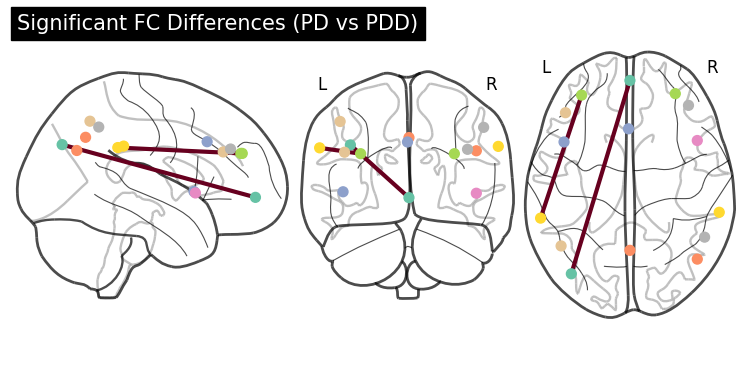

In [229]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_pd = group_array == "PD"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
print(f"p_values: {p_values.flatten()[list_index]}")
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "PD", group2 = "PDD")


In [230]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_PD_PDD")

Significant (uncorrected): 8
Feature 0: decrease (group2 < group1)
Feature 1: decrease (group2 < group1)
Feature 8: decrease (group2 < group1)
Feature 29: decrease (group2 < group1)
Feature 32: decrease (group2 < group1)
Feature 33: decrease (group2 < group1)
Feature 37: decrease (group2 < group1)
Feature 78: increase (group2 > group1)
p_values: [0.03156806 0.02917543 0.0280388  0.04794557 0.02291079 0.01263796
 0.00551602 0.04794557]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.AInsula (L) (-44,13,1)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.RPFC (R) (32,46,27)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPF

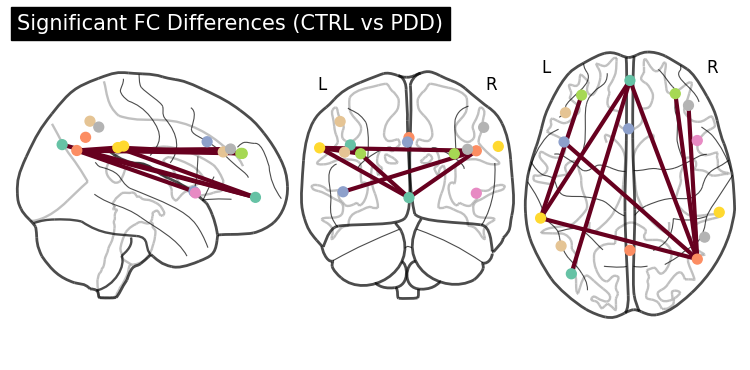

In [231]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
print(f"p_values: {p_values.flatten()[list_index]}")
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PDD")

In [232]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PDD")

Significant (uncorrected): 6
Feature 24: decrease (group2 < group1)
Feature 33: decrease (group2 < group1)
Feature 37: decrease (group2 < group1)
Feature 55: decrease (group2 < group1)
Feature 59: decrease (group2 < group1)
Feature 92: decrease (group2 < group1)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.Salience.ACC (0,22,35) <-> networks.Salience.SMG (R) (62,-35,32)
networks.Salience.ACC (0,22,35) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.SMG (L) (-60,-39,31) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0


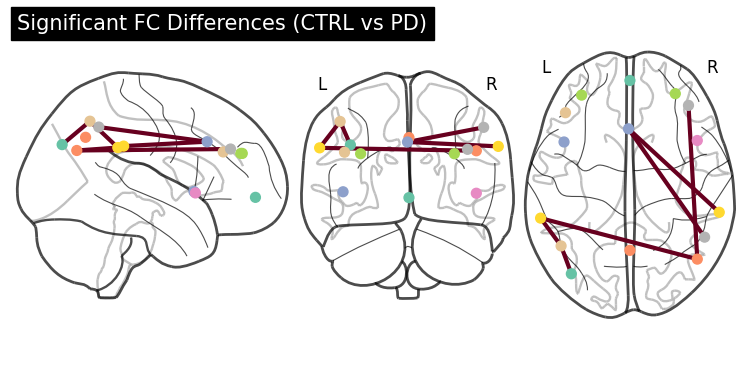

In [233]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PD")

In [234]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PD")

#**BRAIN GLASS**

In [235]:
coordinates = obtain_coordinates()
names_list = get_list_names()
color_list = get_colors(len(coordinates))

view = plotting.view_markers(
    marker_coords=coordinates,
    marker_labels=names_list,
    marker_color=color_list,
    marker_size = 10,
    title = "Regions of Interest (ROIs) Included in the Analysis"
)
view

In [242]:
get_list_names()

['DMN.MPFC',
 'DMN.LP (L)',
 'DMN.LP (R)',
 'DMN.PCC',
 'SAL.ACC',
 'SAL.AInsula (L)',
 'SAL.AInsula (R)',
 'SAL.RPFC (L)',
 'SAL.RPFC (R)',
 'SAL.SMG (L)',
 'SAL.SMG (R)',
 'FPN.LPFC (L)',
 'FPN.PPC (L)',
 'FPN.LPFC (R)',
 'FPN.PPC (R)']

#**ADDITIONAL METRICS**

In [238]:
def compute_group_stats(age, sex, gds):
    N = len(age)

    age_mean = np.mean(age)
    age_std  = np.std(age)

    n_male = np.sum(np.array(sex) == "M")
    n_female = np.sum(np.array(sex) == "F")

    gds_mean = np.mean(gds)
    gds_std  = np.std(gds)

    return {
        "N": N,
        "age": f"{age_mean:.2f} ± {age_std:.2f}",
        "sex": f"{n_male}/{n_female}",  # M/F
        "gds": f"{gds_mean:.2f} ± {gds_std:.2f}"
    }

In [239]:
batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)


age_pd = get_age_list(list_participants_pd)
age_pdd = get_age_list(list_participants_pdd)
age_ctrl = get_age_list(list_participants_ctrl)


sex_pd = get_sex_list(list_participants_pd)
sex_pdd = get_sex_list(list_participants_pdd)
sex_ctrl = get_sex_list(list_participants_ctrl)

gdsc_pd = get_gdsc_list(list_participants_pd)
gdsc_pdd = get_gdsc_list(list_participants_pdd)
gdsc_ctrl = get_gdsc_list(list_participants_ctrl)

In [240]:
stats_ctrl = compute_group_stats(age_ctrl, sex_ctrl, gdsc_ctrl)
stats_pd   = compute_group_stats(age_pd, sex_pd, gdsc_pd)
stats_pdd  = compute_group_stats(age_pdd, sex_pdd, gdsc_pdd)

In [241]:
print(f"""
Group | N | Age (mean ± SD) | Sex (M/F) | GDS (mean ± SD)
--------------------------------------------------------
CTRL  | {stats_ctrl['N']} | {stats_ctrl['age']} | {stats_ctrl['sex']} | {stats_ctrl['gds']}
PD    | {stats_pd['N']}   | {stats_pd['age']}   | {stats_pd['sex']}   | {stats_pd['gds']}
PDD   | {stats_pdd['N']}  | {stats_pdd['age']}  | {stats_pdd['sex']}  | {stats_pdd['gds']}
""")


Group | N | Age (mean ± SD) | Sex (M/F) | GDS (mean ± SD)
--------------------------------------------------------
CTRL  | 32 | 65.67 ± 12.37 | 18/14 | nan ± nan
PD    | 32   | 64.06 ± 10.52   | 19/13   | 1.03 ± 1.31
PDD   | 26  | 62.91 ± 9.73  | 18/8  | 6.88 ± 2.29

